<a href="https://colab.research.google.com/github/elangbijak4/multi-agent-AI/blob/main/Hyperparameter_Tuning1_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Iter 00 | alpha=4.1753 | loss=264.947
Iter 01 | alpha=0.8532 | loss=252.713
Iter 02 | alpha=0.0356 | loss=252.268
Iter 03 | alpha=4.1753 | loss=264.947
Iter 04 | alpha=20.4336 | loss=523.565
Iter 05 | alpha=0.8532 | loss=252.713
Iter 06 | alpha=0.0240 | loss=252.270
Iter 07 | alpha=20.4336 | loss=523.565
Iter 08 | alpha=2.8072 | loss=257.937
Iter 09 | alpha=13.7382 | loss=381.980
Iter 10 | alpha=0.0015 | loss=252.273
Iter 11 | alpha=13.7382 | loss=381.980
Iter 12 | alpha=0.0049 | loss=252.272
Iter 13 | alpha=9.2367 | loss=312.986
Iter 14 | alpha=0.0010 | loss=252.273
Iter 15 | alpha=0.0033 | loss=252.272
Iter 16 | alpha=0.8532 | loss=252.713
Iter 17 | alpha=0.0108 | loss=252.271
Iter 18 | alpha=6.2102 | loss=280.217
Iter 19 | alpha=0.0073 | loss=252.272
Iter 20 | alpha=0.8532 | loss=252.713
Iter 21 | alpha=0.2593 | loss=252.285
Iter 22 | alpha=0.1743 | loss=252.270
Iter 23 | alpha=20.4336 | loss=523.565
Iter 24 | alpha=1.8874 | loss=254.760
Iter 25 | alpha=2.8072 | loss=257.937
Iter 26

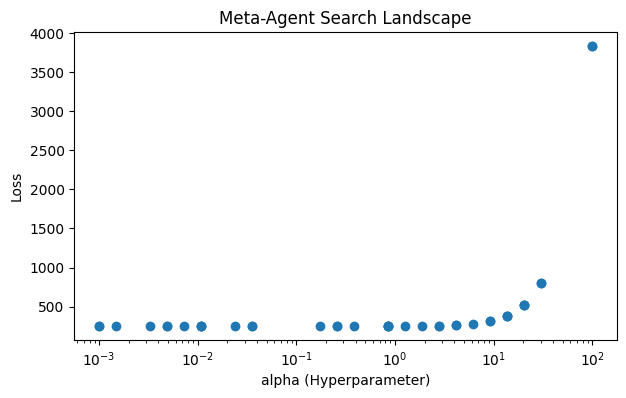

In [1]:
# ============================================================
# AGENT-BASED HYPERPARAMETER OPTIMIZATION DEMO
# Meta-Agent Tuning Learning Policy
# ============================================================

import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt

# ----------------------------
# 1. Environment
# ----------------------------
X, y = make_regression(
    n_samples=300,
    n_features=10,
    noise=15,
    random_state=42
)

# ----------------------------
# 2. Learning Agent Factory
# ----------------------------
def train_agent(alpha):
    """
    alpha = hyperparameter (regularization strength)
    """
    model = Ridge(alpha=alpha)
    scores = cross_val_score(
        model, X, y,
        scoring='neg_mean_squared_error',
        cv=5
    )
    return -scores.mean()

# ----------------------------
# 3. Meta-Agent Definition
# ----------------------------
class HyperparameterAgent:
    def __init__(self, search_space):
        self.search_space = search_space
        self.memory = []

    def perceive(self, alpha):
        loss = train_agent(alpha)
        return loss

    def act(self):
        # Random exploration (stochastic rationality)
        return np.random.choice(self.search_space)

    def learn(self, iterations=30):
        best_alpha = None
        best_loss = float('inf')

        for i in range(iterations):
            alpha = self.act()
            loss = self.perceive(alpha)
            self.memory.append((alpha, loss))

            if loss < best_loss:
                best_loss = loss
                best_alpha = alpha

            print(f"Iter {i:02d} | alpha={alpha:.4f} | loss={loss:.3f}")

        return best_alpha, best_loss

# ----------------------------
# 4. Run Meta-Agent
# ----------------------------
search_space = np.logspace(-3, 2, 30)
meta_agent = HyperparameterAgent(search_space)

best_alpha, best_loss = meta_agent.learn(iterations=40)

print("\nBest Hyperparameter Found:")
print("alpha =", best_alpha)
print("loss  =", best_loss)

# ----------------------------
# 5. Visualization
# ----------------------------
alphas, losses = zip(*meta_agent.memory)

plt.figure(figsize=(7,4))
plt.scatter(alphas, losses)
plt.xscale("log")
plt.xlabel("alpha (Hyperparameter)")
plt.ylabel("Loss")
plt.title("Meta-Agent Search Landscape")
plt.show()